In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from transformers import AutoModelForSequenceClassification
from preprocess_text import load_and_clean_data, get_transformer_dataloaders
from ulti_text import train_and_eval

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

df_train, df_test, target_names = load_and_clean_data()
train_loader, test_loader, tokenizer = get_transformer_dataloaders(df_train, df_test, batch_size=8)

c:\Users\maycha\Desktop\text\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2128.20it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



STARTING TRAINING: Transformer


Epoch 1/5 [Eval]: 100%|██████████| 942/942 [01:28<00:00, 10.65it/s]



Result Epoch 1: Train Loss: 1.0364 | Accuracy: 0.7946 | F1-Score: 0.7842



Epoch 2/5 [Eval]: 100%|██████████| 942/942 [01:25<00:00, 11.06it/s]


...


Result Epoch 3: Train Loss: 0.1653 | Accuracy: 0.8586 | F1-Score: 0.8532



Epoch 4/5 [Eval]: 100%|██████████| 942/942 [01:31<00:00, 10.28it/s]



Result Epoch 4: Train Loss: 0.0906 | Accuracy: 0.8443 | F1-Score: 0.8396



Epoch 5/5 [Eval]: 100%|██████████| 942/942 [01:24<00:00, 11.16it/s]



Result Epoch 5: Train Loss: 0.0695 | Accuracy: 0.8524 | F1-Score: 0.8461



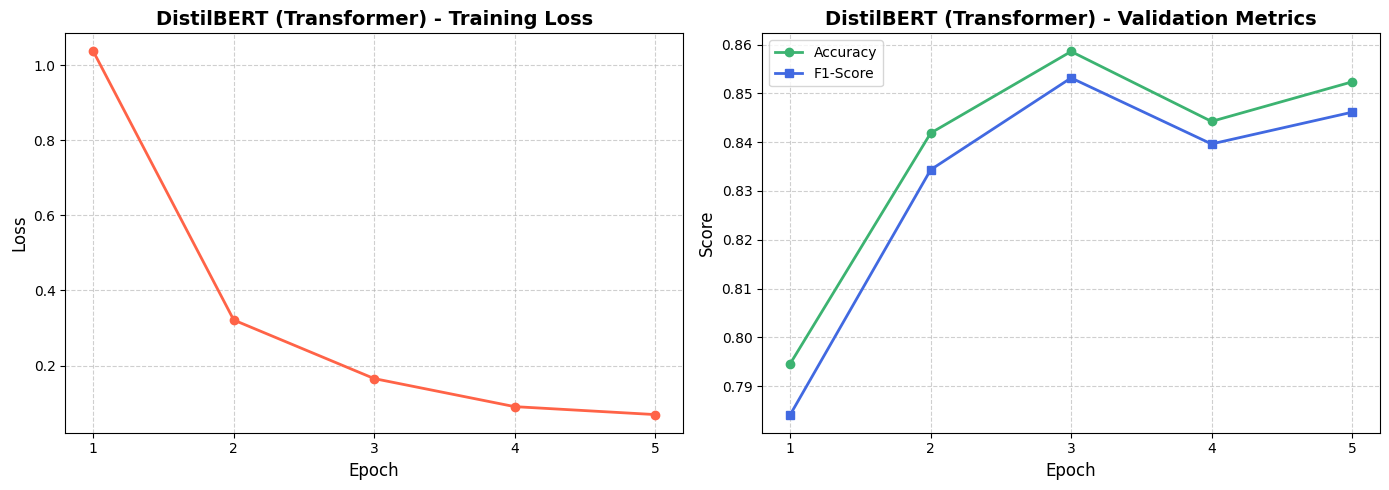

In [2]:
import gc
import matplotlib.pyplot as plt

def plot_learning_curves(history, title):
    epochs_range = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], 'o-', color='tomato', linewidth=2)
    plt.title(f'{title} - Training Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.xticks(epochs_range)
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['val_acc'], 'o-', color='mediumseagreen', label='Accuracy', linewidth=2)
    plt.plot(epochs_range, history['val_f1'], 's-', color='royalblue', label='F1-Score', linewidth=2)
    plt.title(f'{title} - Validation Metrics', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.xticks(epochs_range)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

torch.cuda.empty_cache()
gc.collect()

model_trans = AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=20).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model_trans.parameters(), lr=2e-5)

history_trans = train_and_eval(
    model_trans, train_loader, test_loader, optimizer, criterion, device, 
    epochs=5, model_type="Transformer"
)

plot_learning_curves(history_trans, "DistilBERT (Transformer)")

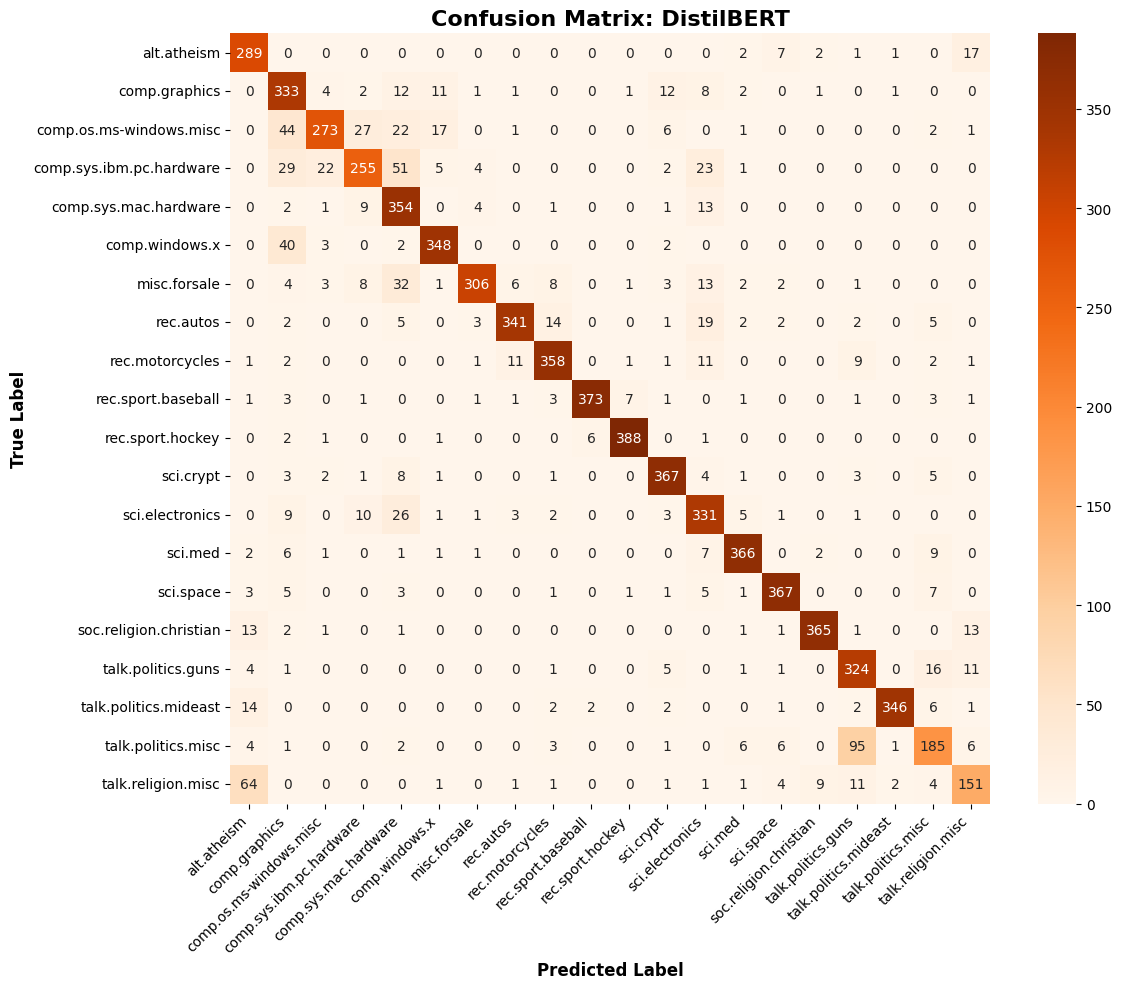

In [3]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_transformer_confusion_matrix(model, test_loader, device, target_names, title):
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Confusion Matrix: {title}', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

plot_transformer_confusion_matrix(model_trans, test_loader, device, target_names, "DistilBERT")

In [4]:
import gradio as gr
import torch.nn.functional as F

model_trans.eval()

def predict_text(text):
    if not text.strip(): return {"Please enter some text": 1.0}
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=256).to(device)
    with torch.no_grad(): probs = F.softmax(model_trans(**inputs).logits, dim=1)[0]
    top_probs, top_indices = torch.topk(probs, 3)
    return {target_names[top_indices[i].item()]: top_probs[i].item() for i in range(3)}

demo = gr.Interface(
    fn=predict_text,
    inputs=gr.Textbox(lines=5, label="Input English text"),
    outputs=gr.Label(num_top_classes=3),
    title="20 Newsgroups Classification Demo (DistilBERT)"
)
demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://1d6cd527e5d93e65f9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
